# Dimensionality Reduction on Handwritten Digits

This demo compares PCA, t-SNE, and UMAP on the sklearn digits dataset to visualize high-dimensional data in 2D.

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Makes plots cleaner
plt.style.use('default')

## 1. Load and Inspect Data

**Dataset:** MNIST-like handwritten digits from scikit-learn
- Size: 1,797 samples
- Dimensions: 64 (8x8 pixel images, flattened)
- Classes: 10 (digits 0-9)

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print("Shape of data:", X.shape)

Shape of data: (1797, 64)


### Visualize a few samples

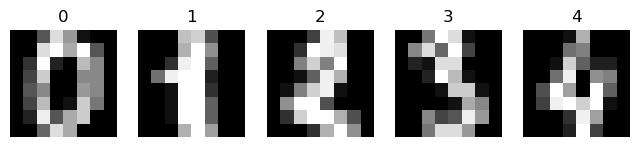

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(8,2))
for i in range(5):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(y[i])
    axes[i].axis('off')
plt.show()

### Our goal: project all of this down to 2D while keeping the digits that look alike close together

## 2. Preprocessing (Standardization)

- Each pixel value gets rescaled so the mean is zero and the standard deviation is one.
- Standardize so each feature contributes equally to distance calculations.
- t-SNE and UMAP both perform better as they rely on distances between points.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original data range: [{X.min():.2f}, {X.max():.2f}]")
print(f"Scaled data range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")

Original data range: [0.00, 16.00]
Scaled data range: [-3.01, 42.38]


## 3. Helper Function for Plotting

In [5]:
def plot_embedding(X_embedded, title):
    plt.figure(figsize=(6,5))
    scatter = plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y,
        cmap='tab10',
        s=10
    )
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

## 4. PCA (Principal Component Analysis)

- Linear dimensionality reduction
- Preserves maximum variance

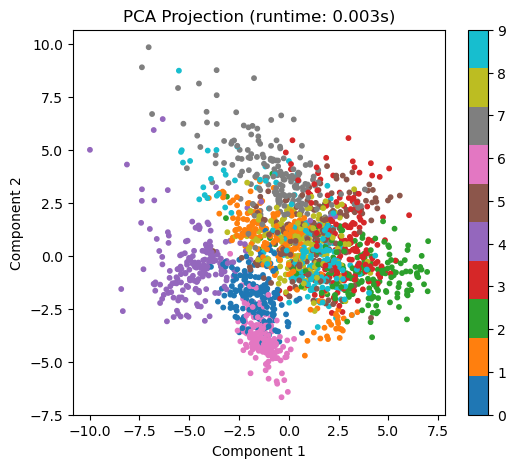

In [6]:
start = time.time()
pca = PCA(n_components=2)
# Fit the model with X and apply the dimensionality reduction on X.
X_pca = pca.fit_transform(X_scaled)
pca_time = time.time() - start

plot_embedding(X_pca, f"PCA Projection (runtime: {pca_time:.3f}s)")

### Interpretation

- PCA is linear and variance-maximizing.
- Digits with similar stroke patterns cluster, but boundaries overlap because PCA cannot model nonlinear structure.

## 5. t-SNE (t-Distributed Stochastic Neighbor Embedding)

- Focuses on preserving local structure
- Good for clustering visualization

### Best practice: PCA -> t-SNE pipeline

- This reduces noise and speeds up t-SNE
- As recommended from the sklearn docs, 50 is a good number of dimensions to reduce to

In [7]:
X_pca50 = PCA(n_components=50).fit_transform(X_scaled)

### Perplexity Sweep

- Perplexity is related to the number of nearest neighbors that is used in other manifold learning algorithms. (sklearn)

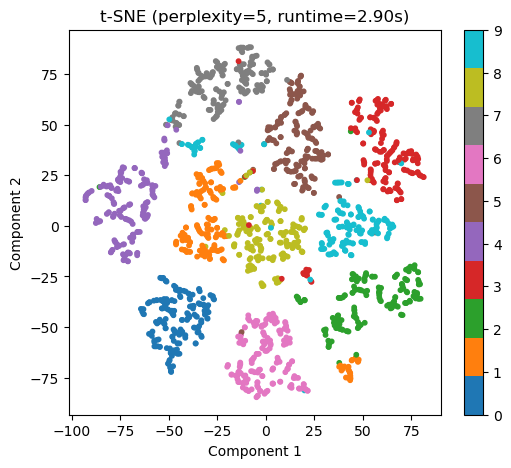

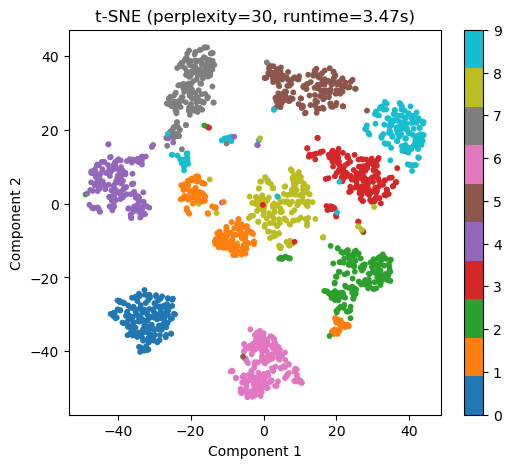

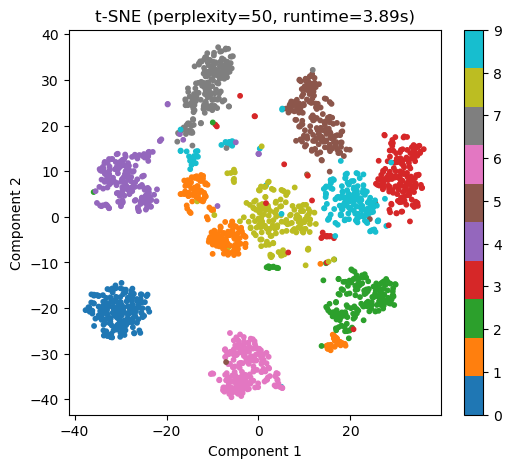

In [8]:
# Perplexity is a key hyperparameter for t-SNE that controls the balance between 
# local and global structure in the data.
perplexities = [5, 30, 50]
tsne_results = {}
tsne_times = {}

for p in perplexities:
    start = time.time()
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X_pca50)
    tsne_times[p] = time.time() - start
    tsne_results[p] = X_tsne
    plot_embedding(X_tsne, f"t-SNE (perplexity={p}, runtime={tsne_times[p]:.2f}s)")

### Interpretation

- Low perplexity (5): very tight micro-clusters
- Medium (30): balanced global/local structure
- High (50): smoother clusters, less fragmentation

t-SNE excels at local neighborhoods but distorts global distances.

## 6. UMAP (Uniform Manifold Approximation and Projection)

- Preserves local and global structure
- Faster than t-SNE

### Default UMAP

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


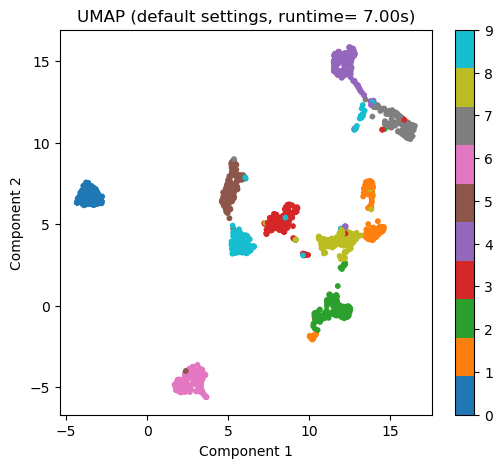

In [9]:
start = time.time()
umap_default = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_default.fit_transform(X_scaled)
umap_time = time.time() - start

plot_embedding(X_umap, f"UMAP (default settings, runtime={umap_time: .2f}s)")

### UMAP Hyperparameter Sweep

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


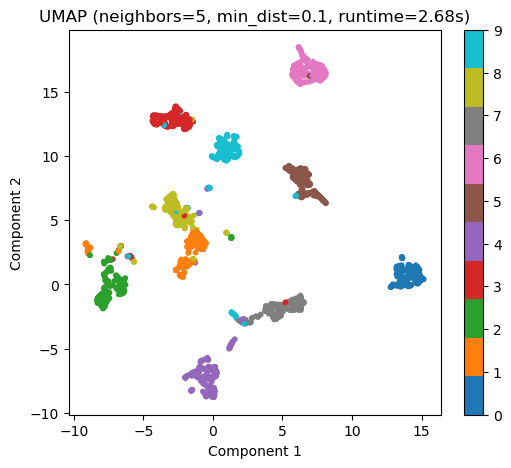

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


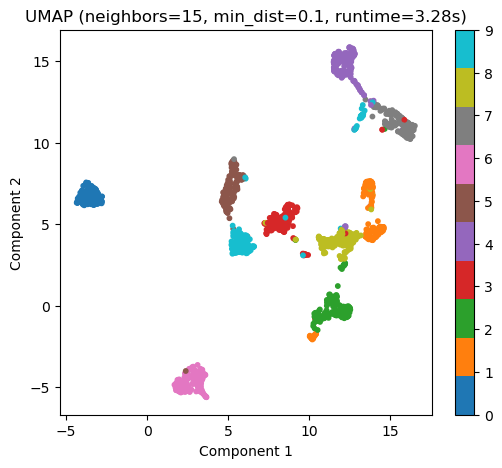

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


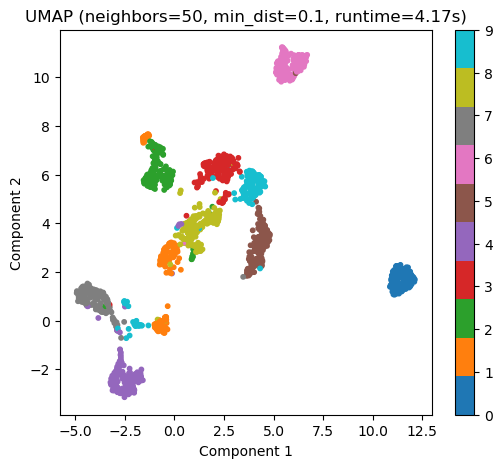

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


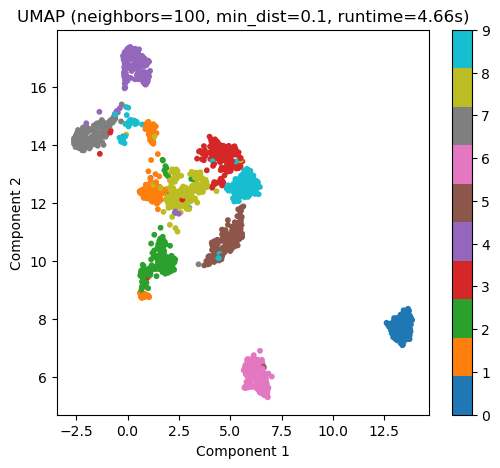

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


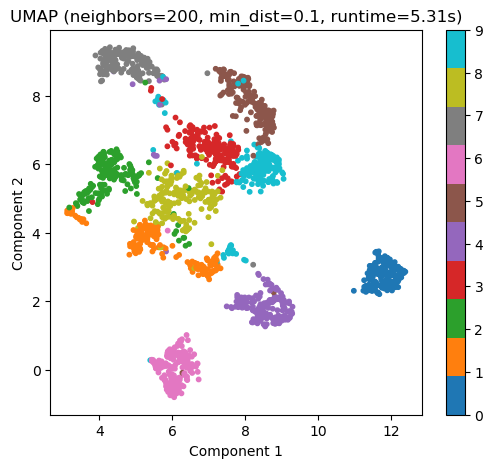

In [10]:
# n_neighbors: Controls the local neighborhood size used for manifold approximation.
# min_dist: Controls how tightly UMAP packs points together in the low-dimensional space.
configs = [
    {"n_neighbors": 5, "min_dist": 0.1},
    {"n_neighbors": 15, "min_dist": 0.1}, # Default
    {"n_neighbors": 50, "min_dist": 0.1},
    {"n_neighbors": 100, "min_dist": 0.1},
    {"n_neighbors": 200, "min_dist": 0.1},
]

for cfg in configs:
    start = time.time()
    reducer = umap.UMAP(
        n_neighbors=cfg["n_neighbors"],
        min_dist=cfg["min_dist"],
        random_state=42
    )
    X_u = reducer.fit_transform(X_scaled)
    t = time.time() - start
    title = f"UMAP (neighbors={cfg['n_neighbors']}, min_dist={cfg['min_dist']}, runtime={t:.2f}s)"
    plot_embedding(X_u, title)

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


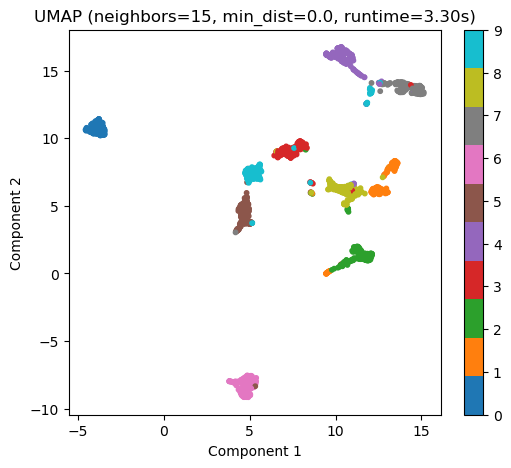

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


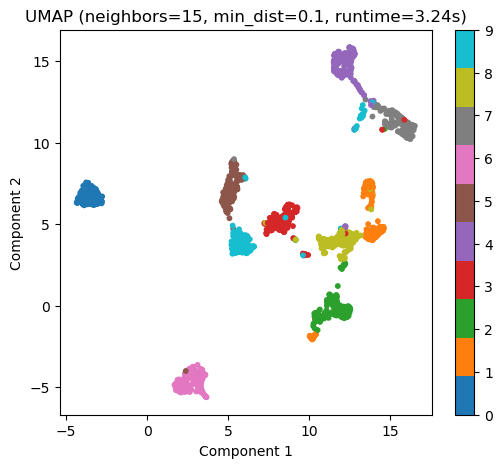

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


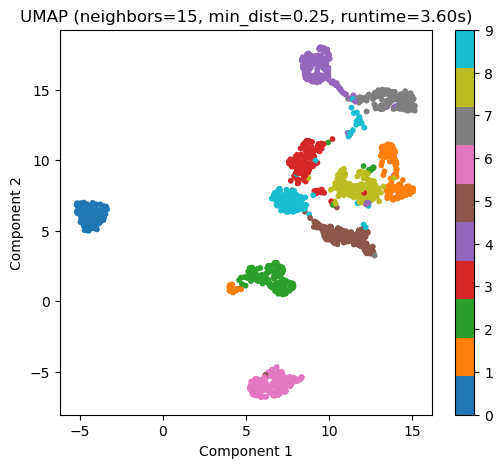

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


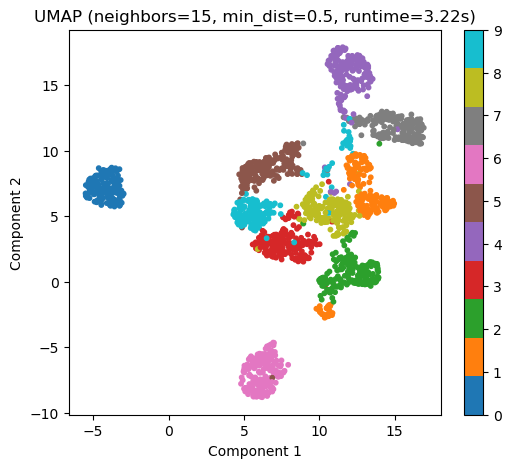

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


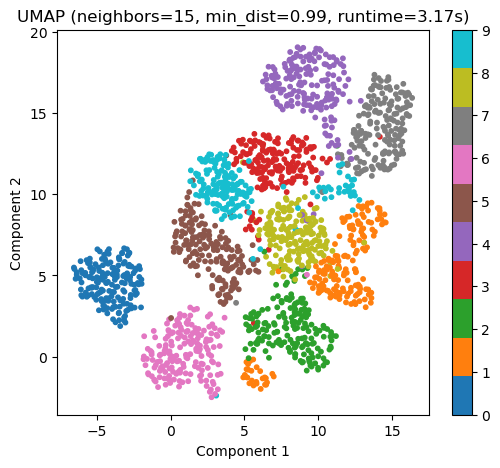

In [11]:
# n_neighbors: Controls the local neighborhood size used for manifold approximation.
# min_dist: Controls how tightly UMAP packs points together in the low-dimensional space.
configs = [
    {"n_neighbors": 15, "min_dist": 0.0},
    {"n_neighbors": 15, "min_dist": 0.1}, # Default
    {"n_neighbors": 15, "min_dist": 0.25},
    {"n_neighbors": 15, "min_dist": 0.5},
    {"n_neighbors": 15, "min_dist": 0.99},
]

for cfg in configs:
    start = time.time()
    reducer = umap.UMAP(
        n_neighbors=cfg["n_neighbors"],
        min_dist=cfg["min_dist"],
        random_state=42
    )
    X_u = reducer.fit_transform(X_scaled)
    t = time.time() - start
    title = f"UMAP (neighbors={cfg['n_neighbors']}, min_dist={cfg['min_dist']}, runtime={t:.2f}s)"
    plot_embedding(X_u, title)

### Interpretation

- n_neighbors small -> very local clusters
- n_neighbors large -> more global structure
- min_dist small -> tight clusters
- min_dist large -> smoother, more spread out

## 7. Runtime Comparison Table

In [12]:
import pandas as pd

df = pd.DataFrame({
    "Algorithm": ["PCA", "t-SNE (p=5)", "t-SNE (p=30)", "t-SNE (p=50)", "UMAP"],
    "Runtime (s)": [
        pca_time,
        tsne_times[5],
        tsne_times[30],
        tsne_times[50],
        umap_time
    ]
})

df

,Algorithm,Runtime (s)
0,PCA,0.003162
1,t-SNE (p=5),2.904874
2,t-SNE (p=30),3.470058
3,t-SNE (p=50),3.894338
4,UMAP,6.998430


## How do you choose?

### PCA
- Fast first look
- Need something reproducible and interpretable
- Preprocessing step

### t-SNE
- Care deeply about local cluster structure
- Want the tightest possible visual separation

### UMAP
- Want the best overall local and global picture
- Need to run in reasonable time

## Key Insight

They're all making tradeoffs about which structure to preserve when reducing to 2D. The right one depends on what question you're trying to answer about your data.